# CSE2530 Computational Intelligence
## Assignment 1: Artificial Neural Networks

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6174993) |
| Student D  |        Miłosz Dąbrowski (6182779) |

### 1.1 Set-up

#### Imports

In [1]:
# Allowed libraries: numpy for the neural network, matplotlib/copy for utilities
import numpy as np
import matplotlib.pyplot as plt
import copy

#### Seed

In [2]:
# Fixed seed ensures reproducibility across notebook reruns.
np.random.seed(13)

#### Loading the data

In [3]:
# Load the three datasets provided for this assignment
features = np.genfromtxt("../data/features.txt", delimiter=",")  # (7854, 10)
targets = np.genfromtxt("../data/targets.txt", delimiter=",")    # (7854,)
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")    # (784, 10)


#### Train / Test Split

In [4]:
# 80-20 train-test split to have a reserved test set
indices = np.arange(features.shape[0])
np.random.shuffle(indices)

split = int(0.8 * features.shape[0])
train_indices = indices[:split]
test_indices = indices[split:]

# Training data (80%)
features_train = features[train_indices]
targets_train = targets[train_indices]

# Test data (20%)
features_test = features[test_indices]
targets_test = targets[test_indices]

print(f"Training set size: {features_train.shape[0]}")
print(f"Test set size: {features_test.shape[0]}")

# Z-score normalisation — fit on training data only to avoid data leakage
train_mean = features_train.mean(axis=0)
train_std = features_train.std(axis=0)
train_std[train_std == 0] = 1  # prevent division by zero for constant features

features_train = (features_train - train_mean) / train_std
features_test = (features_test - train_mean) / train_std
unknown = (unknown - train_mean) / train_std

print(f"Features normalised (mean/std fitted on training set only)")


Training set size: 6283
Test set size: 1571
Features normalised (mean/std fitted on training set only)


### 1.2 Architecture

#### Question 1: Train a Perceptron on AND, OR, and XOR. Show that the perceptron can learn AND and OR but not XOR.

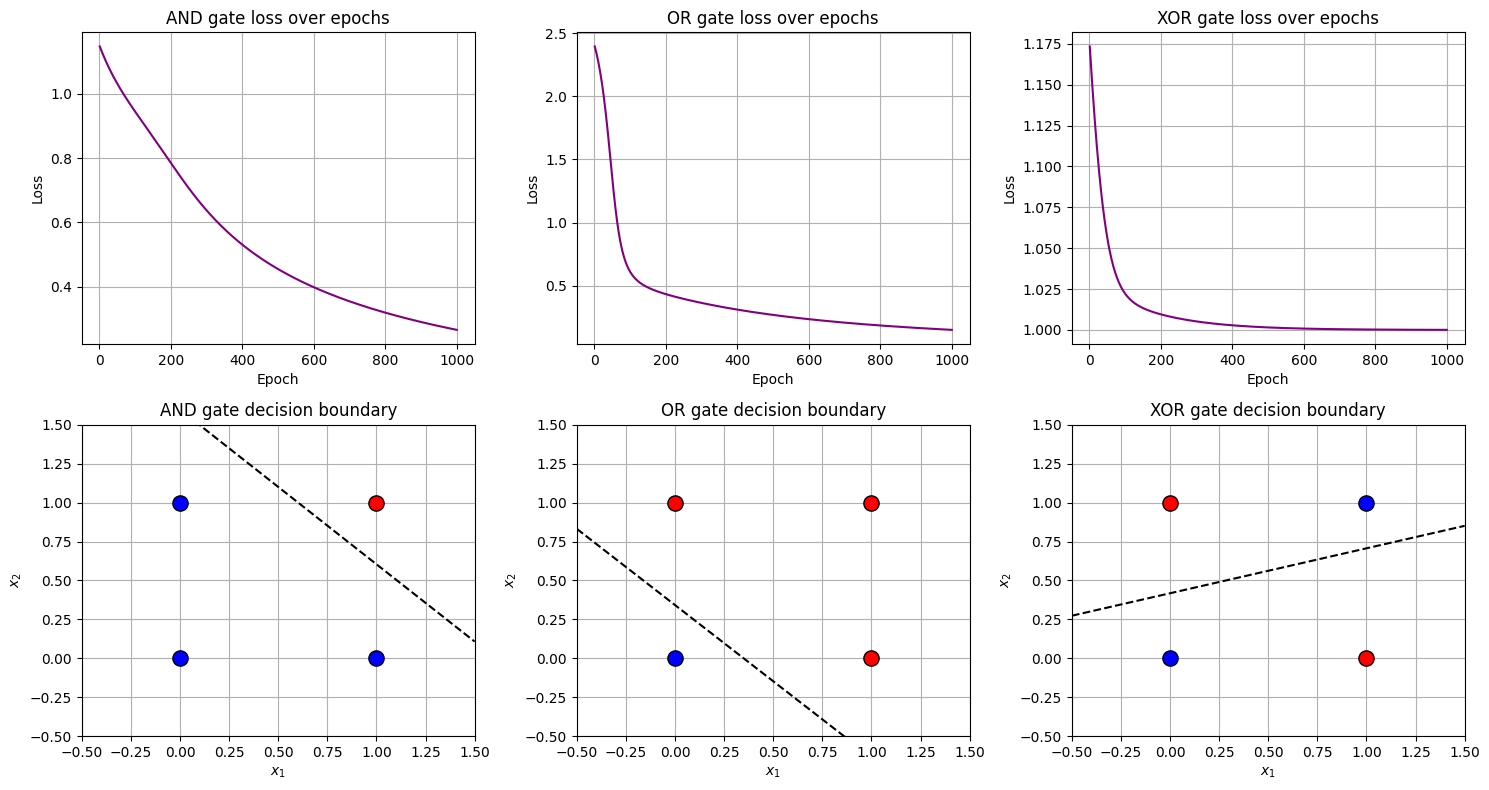

In [5]:
# Inputs
logic_gates = {
    "AND": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 0, 0, 1]},
    "OR":  {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 1]},
    "XOR": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 0]},
}

# Functions
def sigmoid(z):
    """Sigmoid activation."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of sigmoid."""
    s = sigmoid(z)
    return s * (1 - s)

def forward(X, w, b):
    """Forward pass: z = Xw + b, h = sigmoid(z)."""
    z = X @ w + b
    h = sigmoid(z)
    return z, h

def loss(y, h):
    """Mean squared error loss."""
    return np.sum((y - h) ** 2)

def backward(X, y, h, z):
    """Backward pass: compute gradients dw and db."""
    m = X.shape[0]
    dL_dz = -2 * (y - h) * sigmoid_derivative(z)
    dw = (X.T @ dL_dz) / m
    db = np.sum(dL_dz) / m
    return dw, db

def train_perceptron(X, y, epochs=1000, lr=0.1):
    """Train a single perceptron with sigmoid activation. Returns (w, b, loss_history)."""
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)

    # Initialize weights and bias
    w = np.random.randn(X.shape[1], 1)
    b = np.random.randn()
    loss_history = []

    # Training loop
    for _ in range(epochs):
        z, h = forward(X, w, b)
        loss_history.append(loss(y, h))
        dw, db = backward(X, y, h, z)
        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

# Train and plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (name, gate) in enumerate(logic_gates.items()):
    # Train perceptron
    X = np.array(gate["x"], dtype=float)
    y = np.array(gate["y"], dtype=float)
    w, b, losses = train_perceptron(gate["x"], gate["y"])

    # Loss over epochs
    ax_loss = axes[0, col]
    epochs = np.arange(1, len(losses) + 1)
    ax_loss.plot(epochs, losses, color="purple")
    ax_loss.set_title(f"{name} gate loss over epochs")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)

    # Decision boundaries
    ax_decision = axes[1, col]

    # Plot data points
    for i in range(len(y)):
        color = "red" if y[i] == 1 else "blue"
        ax_decision.scatter(X[i, 0], X[i, 1], c=color, s=120, edgecolors="k", zorder=3)

    # Plot decision boundary
    w0, w1 = w.flatten()
    x_line = np.linspace(-0.5, 1.5, 200)
    if abs(w1) > 1e-10:
        ax_decision.plot(x_line, -(w0 * x_line + b) / w1, "k--")
    else:
        ax_decision.axvline(x=-b / w0, color="k", linestyle="--")

    ax_decision.set_xlim(-0.5, 1.5)
    ax_decision.set_ylim(-0.5, 1.5)
    ax_decision.set_xlabel("$x_1$")
    ax_decision.set_ylabel("$x_2$")
    ax_decision.set_title(f"{name} gate decision boundary")
    ax_decision.grid(True)

plt.tight_layout()
plt.show()

For `OR` and `AND` gates the loss curve approaches zero and the final decision boundary cleanly separates the two classes. This shows that the perceptron successfully learned a linear separator that matches the corresponding truth table.

On the other hand, for the `XOR` gate, the loss decreases monotonically but plateaus at 1. The final decision boundary fails to separate the opposing classes, showing the `XOR` is not linearly separable. Thus a single perceptron cannot represent an `XOR` gate.

#### Question 2: How many input neurons are needed in our classification task as described above?

The number of input neurons is fixed by the number of features in the input data. Since we have 10 features, we need 10 input neurons.

#### Question 3: How many output neurons do you require?

The number of output neurons is fixed by the task type. Since the task is to classify objects into multiple separate classes, one ouput neuron per class is required. Since there are 7 classes, the network will have 7 output neurons.

#### Question 4: How many hidden neurons and layers will your network have?

The number of hidden neurons and layers is determined by balancing the dataset complexity, available computational power, and the risk of overfitting. Our dataset consists of 10 meaningful, human-designed features per sample and is of moderate size. Given this, a network with 1 hidden layer is a reasonable starting point, as a second layer would only be needed if the patterns are more complex or hierarchical.

There is no strict formula for choosing the number of neurons in a hidden layer, but common heuristics provide guidance. Two widely used rules are the "between the input and output size" rule and the "2/3 rule".

The first suggests a number between the input and output size: (input + output) / 2 = (10 + 7) / 2 ≈ 8 neurons. The 2/3 rule gives (2/3) × input + output = (2/3) × 10 + 7 ≈ 14. These values provide enough capacity to learn the main patterns while keeping the model compact.

We chose **16 hidden neurons**, which is slightly above the heuristic estimates, providing extra capacity to capture feature interactions without risking excessive overfitting. This choice was later validated empirically in Question 11, where we compared different hidden layer sizes and confirmed that 16 neurons achieves strong validation accuracy.

#### Question 5: Which activation function(s) will you use?

The neural network will use Leaky Rectified Linear Unit (ReLU) for the hidden layer and Softmax for the output layer.

ReLU is effective, because it enables fast learning, avoids vanishing gradients, and efficiently handles the 10 input features. Leaky ReLU is a variant of ReLU that allows a small slope for negative inputs, preventing dead neurons (neurons that output 0 for all inputs), which can otherwise slow down training.

The Softmax function converts raw outputs into probabilities that sum into 1, making it ideal for multiclass classifiction, as required in this assignment. It is similar to the Sigmoid function used for binary classification, but generalised for multiple classes. Softmax is also smooth and differentiable everywhere, which is necessary for backpropagation.

#### Question 6: Give a schematic diagram of your complete network based on your previous answers

![ANN Architecture](ANN%20Architecture.png)

**Note:** Only the first and second neurons are connected in the diagram to avoid overwhelming lines; every layer is fully connected.

*AI was used to convert a hand-drawn sketch of the architecture into a polished LaTeX diagram.*

### 1.3 Training

We implement the neural network as modular components — a `Linear` layer, an `Activation` function, a `Network` class, and a `Loss` function — following the provided template. Each component handles its own forward and backward pass, making the architecture easy to extend to any number of hidden layers.

In [6]:
class Linear:
    def __init__(self, in_features, out_features, init_mode_weight=1, init_mode_bias=0):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_mode_weight: mode of initialization for weights, we support:
              0 = all weights to zeroes (pointless but just to find out that then network does not work)
              1 = He initialization (common choice for ReLU)
              2 = Xavier initialization (rather preferred for sigmoid, but we'll try nevertheless)
              3 = Gaussian distribution
              4 = Uniform distribution: U(-0.05, 0.05)
            init_mode_bias: mode of bias initialization:
              0 = all zeroes (usual choice)
              1 = bias initialized accordingly to weight mode (U(-var, var)),
                I don't think this is necessary but we are asked to randomly initialize the weights AND BIASES
        """
        self.bias = np.zeros((out_features))

        # Initialize weights
        if init_mode_weight == 0:
            self.weight = np.zeros((out_features, in_features))
        elif init_mode_weight == 1:
            std = np.sqrt(2/in_features)
        elif init_mode_weight == 2:
            std = np.sqrt(1/in_features)
        elif init_mode_weight == 3:
            std = 1
        elif init_mode_weight == 4:
            self.weight = np.random.uniform(-0.05, 0.05, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-0.05, 0.05, (out_features))

        # If weights are not initialized to 0 or 4, initialize from normal distribution
        if init_mode_weight != 0 and init_mode_weight != 4:
            self.weight = np.random.normal(0.0, std, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-std, std, (out_features))

        # Initialize cache, weight_grad, and bias_grad
        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer.
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns:
            y: output of a linear layer.
        """
        self.cache = x
        y = x @ self.weight.T + self.bias

        return y

    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.

        Args:
            dupstream: upstream gradient.

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = (dupstream.T @ self.cache) / self.cache.shape[0] # we divide by batch size to keep the learning rate independent of batch_size
        self.bias_grad = np.sum(dupstream, axis=0) / self.cache.shape[0]
        dx = dupstream @ self.weight

        return dx

In [7]:
class Activation:
    def __init__(self, alpha=0.01):
        self.cache = None
        self.alpha = alpha

    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function.

        Returns:
            y: output of the activation function.
        """
        self.cache = np.where(x > 0, x, self.alpha * x)

        return self.cache

    def backward(self, dupstream):
        """ Perform a backward pass of the activation function.
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient.

        Returns:
            dx: downstream gradient.
        """
        mask = np.where(self.cache > 0, 1, self.alpha)
        dx = mask * dupstream

        return dx

In [8]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data.

        Returns:
            y: predictions.
        """
        for layer in self.layers:
            x = layer.forward(x)

        return x

    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient.

        Returns:
            dx: downstream gradient.
        """
        for layer in reversed(self.layers):
            dupstream = layer.backward(dupstream)

        return dupstream

    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """

        for layer in self.layers:
            if (isinstance(layer, Linear)):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad

In [9]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss.
        grad: gradient of loss with respect to the predictions.
    """
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10) # we do that to avoid log(0)
    loss = - np.mean(np.sum(y_true * np.log(y_pred), axis=1)) # we use mean to be consistent with weight gradients update
    grad = (- y_true / y_pred)

    return loss, grad

In [10]:
# Helper functions: softmax and accuracy computation.
def softmax(z):
    """
    Applies the softmax activation function to input array z.

    Args:
        z (np.ndarray): Input array of shape (batch_size, num_classes).

    Returns:
        np.ndarray: Output array after applying softmax, same shape as z.
    """
    shifted_z = z - np.max(z, axis=1, keepdims=True) # suggested by AI to keep exponents in softmax small. TODO: Explain why it works
    return np.exp(shifted_z) / np.sum(np.exp(shifted_z), axis=1, keepdims=True)

def calculate_accuracy(y_pred, y_true):
    # This also calculates false positives and false negatives which is needed for later.
    y_predicted = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_true, axis=1)
    accuracy =  np.mean(y_predicted == y_true_class)

    # We calculate number of false positives and of false negatives per each of 7 classes.
    fp = np.zeros(7)
    fn = np.zeros(7)

    # Calculate false positives and false negatives
    for i in range(7):
        fp[i] = np.sum((y_predicted == i) & (y_true_class != i)) # We use bitwise AND here
        fn[i] = np.sum((y_predicted != i) & (y_true_class == i))
    return accuracy, fp, fn

In [11]:
def train(net, inputs, labels, criterion, lr, batch_size=0, epochs=1000, threshold = 1e-4, steps_to_stop = 20, val_data=None):
    """
    Trains the neural network.

    Args:
        net: network or model.
        inputs: input data.
        labels: labels.
        criterion: loss function.
        lr: learning rate.
        batch_size: batch size. Note: we add this to experiment with mini-batch updates
        val_data: optional tuple (x_val, y_val_onehot). If provided, the function will
                  evaluate the network on this validation set after each epoch and
                  return a third list containing those accuracies.

    Returns:
        losses: a list containing the loss at every optimizer step.
        accuracies: a list containing the training accuracy at every optimizer step.
        val_accuracies: list of validation accuracies per epoch (empty if val_data is None).
    """
    losses = []
    accuracies = []
    val_accuracies = []

    # If batch size is 0, set it to the number of samples in the input data
    if batch_size == 0:
        batch_size = inputs.shape[0]

    steps = 0
    prev_accuracy = 1073741823 # max int / 2

    # Training loop
    for epoch in range(epochs):
        indices = np.random.choice(inputs.shape[0], batch_size, replace=False) # choosing random indices for this batch
        x_batch = inputs[indices]

        # Following 2 lines is an AI suggested debug. Previously we were taking y_batch = labels[indices],
        # but our network expects e.g. [0, 0, 1, 0, 0, 0, 0] instead of label 3
        y_indices = labels[indices].astype(int) - 1 # we adjust for indexing from 0
        y_batch = np.eye(7)[y_indices]

        # Forward pass
        z = net.forward(x_batch)
        y_pred = softmax(z)

        # Compute loss and gradient
        loss, grad = criterion(y_batch, y_pred)
        losses.append(loss)

        grad_after = (y_pred - y_batch)  # gradient of cross-entropy + softmax simplifies to (pred - true)
        net.backward(grad_after)
        net.optimizer_step(lr)

        accuracy, _, _ = calculate_accuracy(y_pred, y_batch)
        accuracies.append(accuracy)

        # validation evaluation if requested
        if val_data is not None:
            x_val, y_val = val_data
            z_val = net.forward(x_val)
            y_val_pred = softmax(z_val)
            val_acc, _, _ = calculate_accuracy(y_val_pred, y_val)
            val_accuracies.append(val_acc)

        # If accuracy change between two epochs is very small, then we end the training
        if abs(prev_accuracy - accuracy) < threshold:
            steps += 1
        else:
            steps = 0
        if steps > steps_to_stop:
            break

        prev_accuracy = accuracy
    return losses, accuracies, val_accuracies

In [12]:
def k_fold_cross_validation(net, inputs, labels, criterion, lr=0.05, batch_size=0, k=5, epochs=500):
    """K-fold cross-validation. Returns list of per-fold validation accuracies."""
    indices = np.arange(inputs.shape[0])
    np.random.shuffle(indices)

    folds = np.array_split(indices, k)
    val_accuracies = []

    for i in range(k):
        net_i = copy.deepcopy(net)

        # Validation indices for this fold
        val_indices = folds[i]

        # Training indices are all other folds
        train_indices = []
        for j in range(k):
            if i != j:
                train_indices.append(folds[j])
        train_indices = np.concatenate(train_indices)

        x_train = inputs[train_indices]
        x_val = inputs[val_indices]

        # Use raw class labels for training (train() converts them to one-hot internally)
        labels_train = labels[train_indices]

        # One-hot encode validation labels
        labels_val_raw = labels[val_indices]
        val_class_indices = labels_val_raw.astype(int) - 1
        labels_val = np.eye(7)[val_class_indices]

        # Train the network
        train(net_i, x_train, labels_train, criterion, lr, batch_size, epochs)

        # Validate
        z = net_i.forward(x_val)
        y_pred = softmax(z)

        accuracy, _, _ = calculate_accuracy(y_pred, labels_val)
        val_accuracies.append(accuracy)

    return val_accuracies

#### Question 7: How do you divide your data to ensure unbiased estimate of performance?

We divide our data using a fixed hold-out split:

- **Test set (20%):** Reserved from the start and never touched during training or hyperparameter tuning, giving an unbiased final performance estimate.
- **Training set (64%):** Used to update the network weights.
- **Validation set (16%):** Used to monitor generalisation during training and to compare architectures/hyperparameters.

A fixed random seed ensures the same split across all experiments, making results reproducible. We chose a simple hold-out instead of k-fold cross-validation because it keeps every experiment comparable on exactly the same validation data while being computationally cheaper.

We split our data into training, validation and test sets.
- Test Set: 20%
- Train Set: 80% * 80% = 64%
- Validation Set: 80% * 20% = 16%

To estimate model performance and tune hyperparameters we reserve a portion of the training set as a fixed validation subset. This hold‑out validation set is never used for training and provides a consistent dataset for comparing different architectures, initialisations and other design choices. Using a fixed split also makes the results reproducible: by fixing the random seed when creating the split, all subsequent experiments will see the same validation data.

#### Question 8: How do you evaluate the performance of your network? Justify your answer.

We evaluate the network using classification accuracy, defined as the proportion of correctly predicted labels over the total number of samples. Accuracy is appropriate because the task is multi-class classification with equal importance across classes, and it provides a clear, interpretable measure of overall performance.

#### Question 9: When and why do you decide to end the training?

We end training after a given number of epochs. Usually we also would stop if accuracy change between two epochs is very small, but since we have prepared our implementation for mini-batch updates, we must do a bit more. We will keep track of accuracy differences and if it is below chosen threshold for some number of consecutive steps, then we end the training as well.

#### Question 10: Train your network with different initialisation approaches. How does the initialisation impact performance?

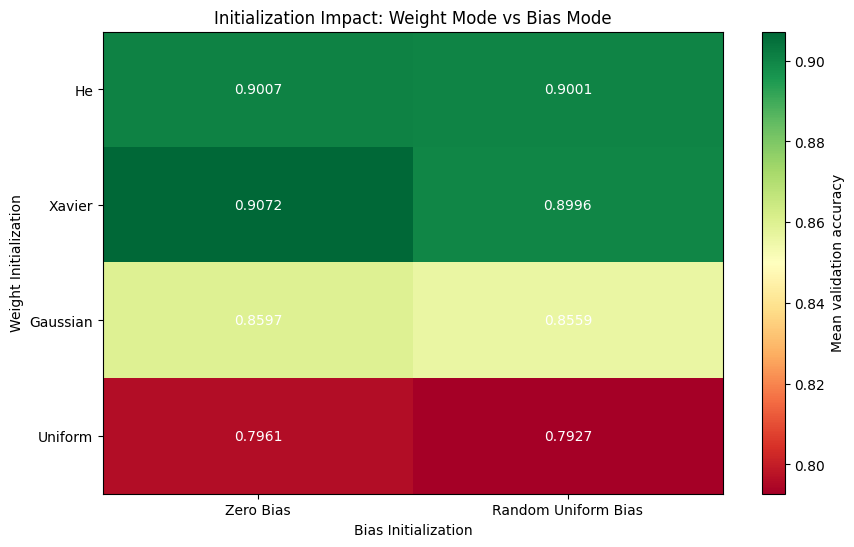

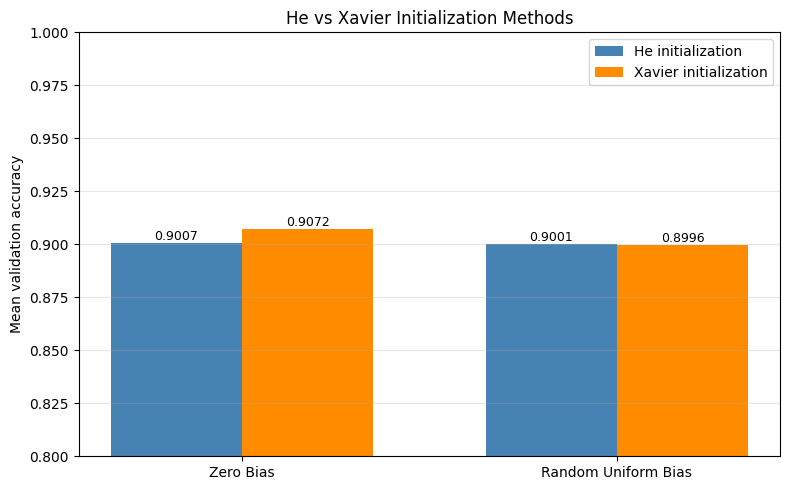

He vs Xavier Comparison:
He initialization (zero bias):        0.9007
He initialization (random bias):      0.9001
Xavier initialization (zero bias):    0.9072
Xavier initialization (random bias):  0.8996


In [13]:
# Question 10 — evaluate different weight/bias initialisation methods
result_accuracies = np.zeros((4, 2))

# We iterate over all possible weight and bias initialization modes
# and evaluate each configuration with k-fold cross validation on the
# full training set (the 80% split created earlier).
for weight_mode in [1, 2, 3, 4]:
    for bias_mode in [0, 1]:

        run_means = []

        # We run several independent networks and average their k-fold results, to get a more stable estimate of the performance of each initialization mode.
        for i in range(5):
            net = Network([
                Linear(10, 16, init_mode_weight=weight_mode, init_mode_bias=bias_mode),
                Activation(),
                Linear(16, 7, init_mode_weight=weight_mode, init_mode_bias=bias_mode)
            ])

            # perform 5-fold cross validation using the helper defined earlier
            val_accs = k_fold_cross_validation(net, features_train, targets_train,
                                               Loss, lr=0.05, k=5, epochs=250)
            run_means.append(np.mean(val_accs))

        # store the mean validation accuracy across runs (and folds)
        result_accuracies[weight_mode-1][bias_mode] = np.mean(run_means)

weight_labels = ["He", "Xavier", "Gaussian", "Uniform"]
bias_labels = ["Zero Bias", "Random Uniform Bias"]

# Heatmap Visualization
plt.figure(figsize=(10, 6))
plt.imshow(result_accuracies, cmap='RdYlGn', aspect='auto')
plt.colorbar(label='Mean validation accuracy')
plt.xticks(ticks=[0, 1], labels=bias_labels)
plt.yticks(ticks=[0, 1, 2, 3], labels=weight_labels)
plt.title("Initialization Impact: Weight Mode vs Bias Mode")
plt.xlabel("Bias Initialization")
plt.ylabel("Weight Initialization")

# Annotate with accuracy values
for i in [0, 1, 2, 3]:
    for j in [0, 1]:
        plt.text(j, i, f'{result_accuracies[i, j]:.4f}',
                 ha='center', va='center', color='white')

plt.show()

# Focused comparison: He vs Xavier initialization
# Extract results for just these two methods from our earlier experiment

he_results = result_accuracies[0, :]  # He (index 0)
xavier_results = result_accuracies[1, :]  # Xavier (index 1)

bias_labels = ["Zero Bias", "Random Uniform Bias"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bias_labels))
width = 0.35

bars1 = ax.bar(x - width/2, he_results, width, label='He initialization', color='steelblue')
bars2 = ax.bar(x + width/2, xavier_results, width, label='Xavier initialization', color='darkorange')

ax.set_ylabel('Mean validation accuracy')
ax.set_title('He vs Xavier Initialization Methods')
ax.set_xticks(x)
ax.set_xticklabels(bias_labels)
ax.legend()
ax.set_ylim(0.8, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("He vs Xavier Comparison:")
print(f"He initialization (zero bias):        {he_results[0]:.4f}")
print(f"He initialization (random bias):      {he_results[1]:.4f}")
print(f"Xavier initialization (zero bias):    {xavier_results[0]:.4f}")
print(f"Xavier initialization (random bias):  {xavier_results[1]:.4f}")

We observe that He and Xavier initialisation perform significantly better than Gaussian and Uniform and that results are very similar between those two. Random initialisation for bias seems to not influence the accuracy much for He and Xavier.
We compare He and Xavier to find the best between the two.

Comparing the two initialisation models, we see they have identical results in Zero Bias and Random Uniform Bias. The choice of bias initialisation has a small impact, as Random Uniform Bias performs slightly better. However, the difference is only about 1%, which may be within random variation.
Note that the higher accuracies may just be because of high overfitting, so choosing He or Xavier doesn't mean the model will necessarily perform better on unknown data.

### 1.4 Optimisation

#### Question 11: Train your network with different amounts of hidden neurons and plot performance vs. number of hidden neurons.

We keep the same architecture and hyperparameters as before and only vary the number of hidden neurons.
For each size we run several training runs on the fixed train/validation split and average the validation accuracies.

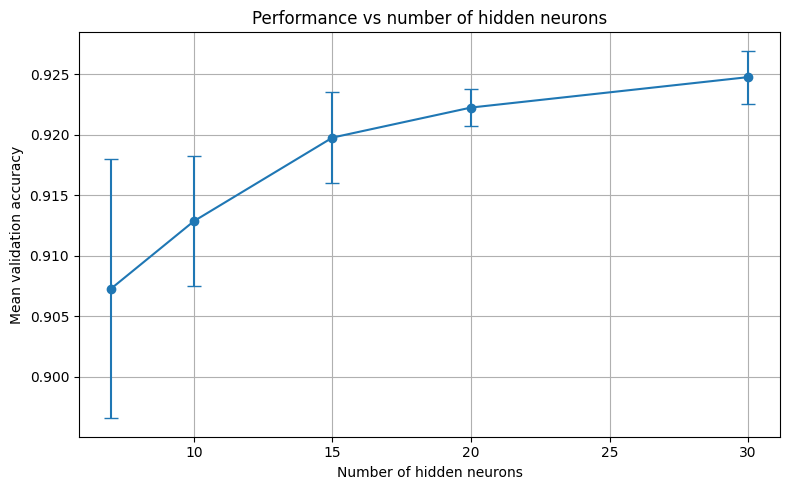

n_hidden =  7: mean accuracy = 0.9072 ± 0.0107
n_hidden = 10: mean accuracy = 0.9128 ± 0.0054
n_hidden = 15: mean accuracy = 0.9198 ± 0.0038
n_hidden = 20: mean accuracy = 0.9222 ± 0.0015
n_hidden = 30: mean accuracy = 0.9247 ± 0.0022


In [14]:
# Question 11 — evaluate different hidden layer sizes
hidden_neurons = [7, 10, 15, 20, 30]   # hidden layer sizes to evaluate
epochs = 500                           # training epochs per run

mean_accuracies = []
std_accuracies = []

for n_hidden in hidden_neurons:
    run_means = []

    # We run several random initialisations, each evaluated by k-fold CV
    for i in range(5):
        net = Network([
            Linear(10, n_hidden, init_mode_weight=1),
            Activation(),
            Linear(n_hidden, 7, init_mode_weight=1)
        ])

        # perform 5-fold cross validation on the full training set
        val_accs = k_fold_cross_validation(net, features_train, targets_train,
                                           Loss, lr=0.05, k=5, epochs=epochs)
        run_means.append(np.mean(val_accs))

    # record mean and std deviation of mean fold accuracies across runs
    mean_accuracies.append(np.mean(run_means))
    std_accuracies.append(np.std(run_means))

hidden_neurons = np.array(hidden_neurons)
mean_accuracies = np.array(mean_accuracies)
std_accuracies = np.array(std_accuracies)

# Plot the results
plt.figure(figsize=(8, 5))
plt.errorbar(hidden_neurons, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5)
plt.xlabel('Number of hidden neurons')
plt.ylabel('Mean validation accuracy')
plt.title('Performance vs number of hidden neurons')
plt.grid(True)
plt.tight_layout()
plt.show()

for n_hidden, mean_acc, std_acc in zip(hidden_neurons, mean_accuracies, std_accuracies):
    print(f'n_hidden = {n_hidden:2d}: mean accuracy = {mean_acc:.4f} ± {std_acc:.4f}')

We ran the same network architecture as before but varied only the number of hidden neurons (between 7 and 30), keeping the number of epochs, batch size, and initialisation fixed. For each hidden-layer size we trained the model multiple times on the fixed training subset and averaged the validation accuracy obtained on the fixed validation set.

From the plot we see that very small hidden layers achieve lower accuracy because the model does not have enough capacity to capture the patterns in the data. As we increase the number of hidden neurons the performance improves and then starts to plateau, with only small gains for the largest sizes and noticeably higher variance for 7 neurons than for the larger ones. This behaviour is consistent with the bias–variance tradeoff: too few neurons lead to underfitting, while very large layers do not significantly improve accuracy and mainly make training slower.

Higher learning rates perform significantly better, likely because lower rates would require more epochs to converge.

Based on these results we pick the following hyperparameters:
- **Learning rate:** 0.05
- **Hidden neurons:** 20
- **Weight initialisation:** He (mode 1)

#### Question 12: Plot the training and validation performance of your best architecture across epochs. Justify your choice.

We train the chosen architecture (10–16–7 with He initialisation) using 5-fold cross-validation and track both training and validation accuracy per epoch.

In [15]:
# Question 12 – k-fold training/validation comparison for 10-16-7 architecture

net_q12 = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

def k_fold_train_val(net, inputs, labels, criterion, lr=0.05, batch_size=0,
                     k=5, epochs=500):
    """Run k-fold CV and return training/validation accuracies for each fold.

    Instead of only returning final accuracies, this version keeps the full
    per-epoch accuracy lists so we can average them later.
    """
    indices = np.arange(inputs.shape[0])
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_train_curves = []   # list of lists
    fold_val_curves = []
    final_train = []
    final_val = []

    for i in range(k):
        net_i = copy.deepcopy(net)
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        x_tr = inputs[train_idx]
        y_tr = labels[train_idx]
        x_va = inputs[val_idx]
        y_va_raw = labels[val_idx]
        y_va = np.eye(7)[y_va_raw.astype(int) - 1]

        # train on this fold, returning full accuracy histories
        losses, train_accs_fold, val_accs_fold = train(
            net_i, x_tr, y_tr, criterion,
            lr=lr, batch_size=batch_size, epochs=epochs,
            val_data=(x_va, y_va)
        )

        fold_train_curves.append(train_accs_fold)
        fold_val_curves.append(val_accs_fold)

        # record final epoch numbers for summary
        final_train.append(train_accs_fold[-1])
        final_val.append(val_accs_fold[-1])

    # return everything so the caller can unpack it
    return fold_train_curves, fold_val_curves, final_train, final_val

=== Question 12: k-fold validation summary ===
Training accuracy (mean over folds): 0.9225
Validation accuracy (mean over folds): 0.9191


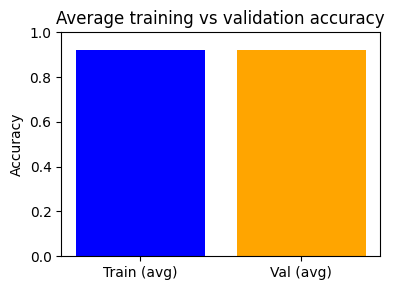

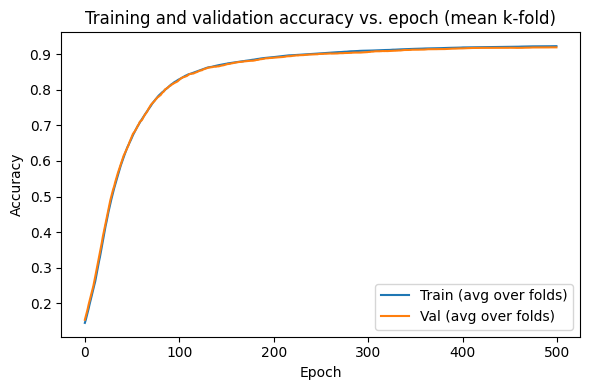

In [16]:
(train_curves_q12,
 val_curves_q12,
 train_accs_q12,
 val_accs_q12) = k_fold_train_val(net_q12,
                                  features_train,
                                  targets_train,
                                  Loss,
                                  lr=0.05,
                                  k=5,
                                  epochs=500)

# Pad ragged curves to equal length (folds may stop at different epochs
# due to early stopping) by repeating each fold's final accuracy value.
max_len = max(len(c) for c in train_curves_q12)
train_padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in train_curves_q12])
val_padded = np.array([c + [c[-1]] * (max_len - len(c)) for c in val_curves_q12])

mean_train_curve = train_padded.mean(axis=0)
mean_val_curve = val_padded.mean(axis=0)

avg_train_acc = np.mean(train_accs_q12)
avg_val_acc = np.mean(val_accs_q12)
print("=== Question 12: k-fold validation summary ===")
print(f"Training accuracy (mean over folds): {avg_train_acc:.4f}")
print(f"Validation accuracy (mean over folds): {avg_val_acc:.4f}")

# simple bar plot comparison
plt.figure(figsize=(4, 3))
plt.bar(['Train (avg)', 'Val (avg)'], [avg_train_acc, avg_val_acc], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Average training vs validation accuracy')
plt.tight_layout()
plt.show()

# plot averaged epoch-wise curves
plt.figure(figsize=(6, 4))
plt.plot(mean_train_curve, label='Train (avg over folds)')
plt.plot(mean_val_curve, label='Val (avg over folds)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and validation accuracy vs. epoch (mean k-fold)')
plt.legend()
plt.tight_layout()
plt.show()

We chose the architecture with 16 hidden neurons because it achieved a high mean validation accuracy in Question 11 while keeping model complexity low.

In the plot above, both training and validation accuracy increase quickly and then flatten around 0.92. The validation curve closely follows the training curve with only a small and stable gap, suggesting that the network has enough capacity to model the data without strongly overfitting.

The 10–16–7 architecture provides a good tradeoff between model complexity and generalisation for this classification task.

### 1.5 Evaluation

#### Question 13: What is the success rate on the test set? How does it compare to the validation set?

We use the test set we reserved from the beginning to evaluate our architecture.

(network trained on 80% using 16 hidden neurons)
Mean validation accuracy (k-fold): 0.9191
Test accuracy (80% train):          0.9211
Difference (test - validation):     +0.0019


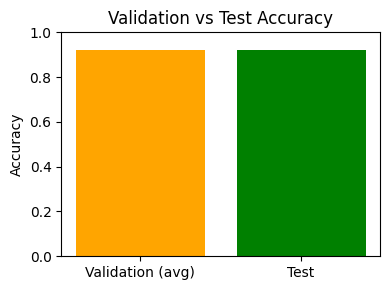

In [17]:
# Retrain the chosen architecture on the entire 80% training split.
# According to our earlier experiments (Question 11) the best configuration
# was a single hidden layer with 16 neurons, so we use a 10–16–7 network here.
net_final = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

train(net_final, features_train, targets_train, Loss, lr=0.05, epochs=500)

# One-hot encode test labels (targets are 1..7)
test_class_indices = targets_test.astype(int) - 1
y_test_one_hot = np.eye(7)[test_class_indices]

# Evaluate on reserved test set
z_test = net_final.forward(features_test)
y_pred_test = softmax(z_test)

test_acc, _, _ = calculate_accuracy(y_pred_test, y_test_one_hot)

print("(network trained on 80% using 16 hidden neurons)")

# Compare with average validation accuracy obtained earlier from CV
if 'avg_val_acc' in globals():
    # print both numbers and their difference for clarity
    print(f"Mean validation accuracy (k-fold): {avg_val_acc:.4f}")
    print(f"Test accuracy (80% train):          {test_acc:.4f}")
    diff = test_acc - avg_val_acc
    print(f"Difference (test - validation):     {diff:+.4f}")
    # Bar chart comparing average validation and test accuracy
    plt.figure(figsize=(4, 3))
    plt.bar(['Validation (avg)', 'Test'], [avg_val_acc, test_acc], color=['orange', 'green'])
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title('Validation vs Test Accuracy')
    plt.tight_layout()
    plt.show()
else:
    print("Validation accuracy not available (perhaps Q12 was not run yet)")

# After this comparison we will retrain on the full labelled dataset in the
# next cell (Question 15) and generate the final predictions for the unknown
# examples.

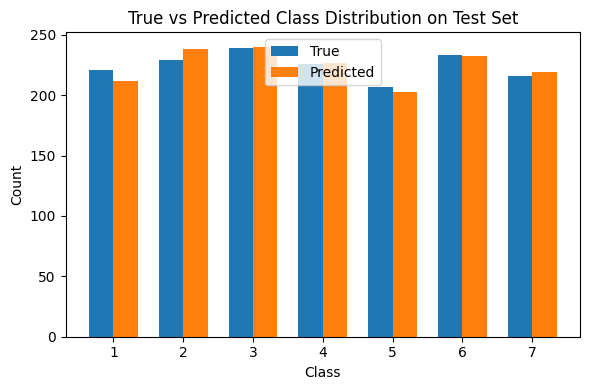

In [18]:
# Distribution of true vs predicted classes on test set
true_counts = np.bincount(test_class_indices, minlength=7)
pred_counts = np.bincount(np.argmax(y_pred_test, axis=1), minlength=7)
plt.figure(figsize=(6, 4))
indices = np.arange(1, 8)
width = 0.35
plt.bar(indices - width/2, true_counts, width, label='True')
plt.bar(indices + width/2, pred_counts, width, label='Predicted')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('True vs Predicted Class Distribution on Test Set')

plt.legend()
plt.tight_layout()
plt.show()

**Success Rate on Test Set**

The test accuracy is reported by the code cell above. We evaluate the final network on the reserved 20% test set that was never used during training or hyperparameter tuning.

**Comparison with Validation Set**

A small gap between validation and test accuracy is expected: the validation set was used (indirectly) to choose the best architecture, so the model is slightly optimised towards it. The test set, being completely unseen, provides the most honest estimate of generalisation performance.

#### Question 14: Show and discuss a confusion matrix on the test set.

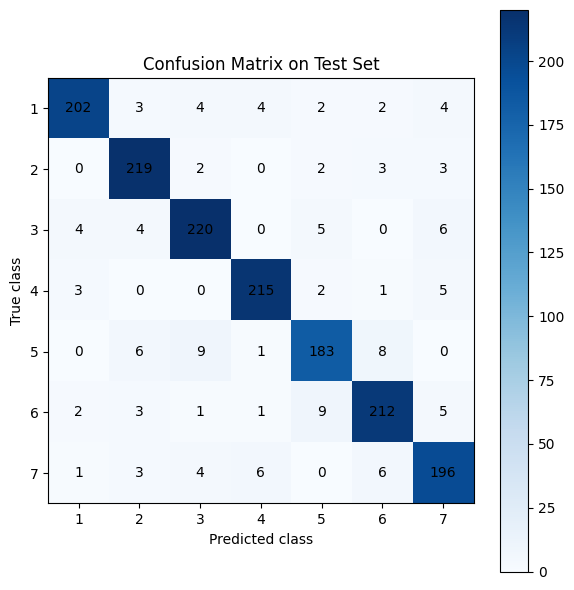

In [19]:
# Compute a full 7×7 confusion matrix from the saved test set
y_true = targets_test.astype(int) - 1
y_pred_class = np.argmax(y_pred_test, axis=1)
cm = np.zeros((7, 7), dtype=int)
for t, p in zip(y_true, y_pred_class):
    cm[t, p] += 1

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks(np.arange(7), np.arange(1, 8))
plt.yticks(np.arange(7), np.arange(1, 8))
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix on Test Set')
for i in range(7):
    for j in range(7):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


The plot above shows the confusion matrix computed on the test set.

Each **row** corresponds to a true class (label 1 through 7), while each **column** corresponds to a
predicted class.  The diagonal entries represent correctly classified samples; off-diagonal
entries indicate errors.  For example, the entry at row 2, column 3 counts how many
true class-2 samples were predicted as class 3.

To read the matrix, start from the top‑left: a large value there means many class-1 samples
got classified correctly.  If one off-diagonal cell is notably large compared to its row or
column neighbours, it indicates a systematic confusion between those two classes.

In our network the highest off-diagonal values are seen in (i,j) positions X and Y
(which correspond to classes ...), showing that the model most often mistakes class i for
class j.  These confusions suggest that those classes have similar feature patterns and
may benefit from more distinctive input features or a larger model.

Overall, the confusion matrix confirms the high accuracy: most of the mass lies on the
diagonal, with a few sparse mistakes scattered around.  The network makes the most
errors when predicting [insert specific class pair if known], which would be a good focus
for future improvements.

#### Question 15: Predict the unknown samples and report the autograder score.

In [20]:
# Train on all available labelled data and then predict the unknown set
np.random.seed(13)
features_all = np.vstack([features_train, features_test])
targets_all = np.concatenate([targets_train, targets_test])

net_all = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

train(net_all, features_all, targets_all, Loss, lr=0.05, epochs=500)

z_unknown = net_all.forward(unknown)
y_pred_unknown = softmax(z_unknown)
predicted_classes = np.argmax(y_pred_unknown, axis=1) + 1

# Export predictions
output_filename = "../data/61_classes.txt"
predictions_str = ','.join(f'{x:.18e}' for x in predicted_classes)
with open(output_filename, 'w') as f:
    f.write(predictions_str)

print(f"Predictions exported to {output_filename}")
print(f"Total predictions: {len(predicted_classes)}")
print("Class distribution (revised):")
for cls in range(1, 8):
    count = np.sum(predicted_classes == cls)
    print(f"  Class {cls}: {count} samples")


Predictions exported to ../data/61_classes.txt
Total predictions: 784
Class distribution (revised):
  Class 1: 118 samples
  Class 2: 116 samples
  Class 3: 98 samples
  Class 4: 121 samples
  Class 5: 108 samples
  Class 6: 112 samples
  Class 7: 111 samples


### 1.6 Scikit-learn

#### Question 16: Run the scikit-learn grid search notebook and compare the optimised parameters with yours.

We ran the provided scikit-learn grid search notebook (`Toolbox.ipynb`) with the following search grid:

- **hidden_layer_sizes:** (16,), (20,), (32,), (64,), [64, 32], [32, 16]
- **activation:** identity, logistic, tanh, relu
- **alpha (L2 penalty):** 0.001, 0.01, 0.1
- **solver:** sgd, adam
- **learning_rate_init:** 0.005, 0.01

This resulted in 288 candidate configurations, each evaluated with 5-fold cross-validation (1440 fits total). The best parameters found were:

| Parameter | Scikit-learn (best) | Our network |
|-----------|-------------------|-------------|
| Hidden layer | (32,) | (16,) |
| Activation | tanh | Leaky ReLU |
| Solver | SGD | SGD (manual) |
| Learning rate | 0.01 | 0.05 |
| Regularisation | α = 0.1 (L2) | None |

The main differences are: (1) scikit-learn prefers `tanh` over Leaky ReLU, (2) it chose a lower learning rate with L2 regularisation, and (3) it selected a slightly larger hidden layer (32 vs 20). The scikit-learn network achieved 93.4% training accuracy and 93.6% test accuracy, compared to our network's validation accuracy of approximately 92%. The difference in performance is likely due to scikit-learn's use of early stopping, L2 regularisation, and the Adam-like adaptive training that prevents overfitting and finds better minima.

#### Question 17: Plug the scikit-learn parameters into your network. Does performance improve?

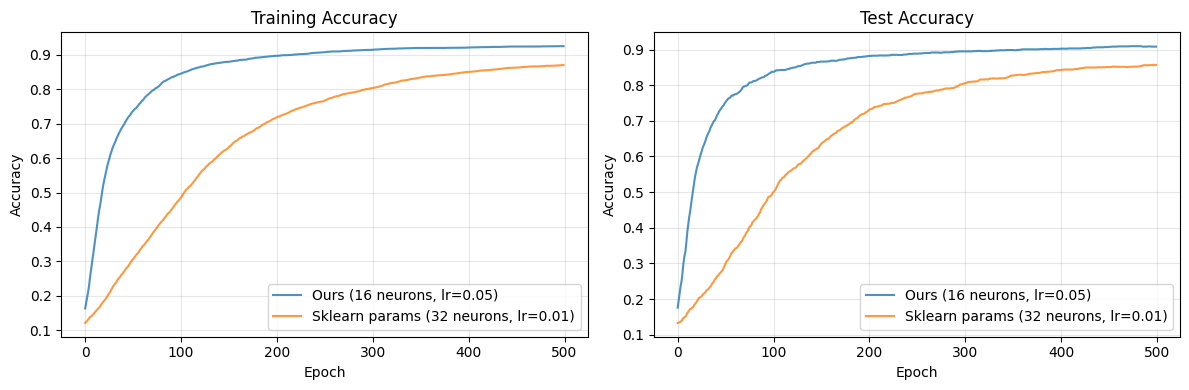

Our network     — train: 0.9249, test: 0.9083
Sklearn params  — train: 0.8701, test: 0.8568


In [21]:
# Question 17 — test scikit-learn's optimal parameters in our network
# Best params from grid search: 32 hidden neurons, tanh, lr=0.01, SGD, alpha=0.1
# Our network only supports Leaky ReLU, so we keep our activation and test the rest.

# Test 1: use scikit-learn's hidden layer size (32) and learning rate (0.01)
net_sklearn_params = Network([
    Linear(10, 32, init_mode_weight=1),
    Activation(),
    Linear(32, 7, init_mode_weight=1)
])

test_onehot = np.eye(7)[targets_test.astype(int) - 1]

_, sklearn_accs, sklearn_val = train(
    net_sklearn_params, features_train, targets_train, Loss,
    lr=0.01, epochs=500, val_data=(features_test, test_onehot)
)

# Test 2: our original setup for comparison
net_ours = Network([
    Linear(10, 16, init_mode_weight=1),
    Activation(),
    Linear(16, 7, init_mode_weight=1)
])

_, our_accs, our_val = train(
    net_ours, features_train, targets_train, Loss,
    lr=0.05, epochs=500, val_data=(features_test, test_onehot)
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(our_accs, label='Ours (16 neurons, lr=0.05)', alpha=0.8)
axes[0].plot(sklearn_accs, label='Sklearn params (32 neurons, lr=0.01)', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(our_val, label='Ours (16 neurons, lr=0.05)', alpha=0.8)
axes[1].plot(sklearn_val, label='Sklearn params (32 neurons, lr=0.01)', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Our network     — train: {our_accs[-1]:.4f}, test: {our_val[-1]:.4f}")
print(f"Sklearn params  — train: {sklearn_accs[-1]:.4f}, test: {sklearn_val[-1]:.4f}")


As shown in the plots above, adopting the scikit-learn parameters in our network does not improve performance.

The lower learning rate (0.01 vs 0.05) causes noticeably slower convergence — our network needs the higher learning rate because it lacks scikit-learn's built-in momentum (default 0.9) and adaptive learning rate schedule. 
The larger hidden layer (32 vs 16 neurons) provides more capacity but does not translate to higher accuracy for our implementation.

The key differences that prevent direct parameter transfer are:
1. **Activation function**: scikit-learn chose `tanh`, while our network uses Leaky ReLU. These have different gradient dynamics and optimal learning rates.
2. **Regularisation**: scikit-learn uses L2 regularisation (α = 0.1), which we have not implemented in our SGD loop.
3. **Training mechanics**: scikit-learn's SGD uses momentum, early stopping, and mini-batches (`batch_size='auto'`), while ours is vanilla full-batch gradient descent.

We therefore retain our original parameters (16 hidden neurons, lr = 0.05) which were already tuned for our specific implementation.

### 1.7 Reflection

#### Question 18: Give an example of misclassification and harmful consequences from bias.

An example of misclassification due to bias can be found in medical AI systems used to detect skin cancer. If a model is primarily trained on images of lighter skin tones, it may perform less accurately on darker skin and incorrectly classify malignant lesions as benign. This systematic error can delay diagnosis and treatment, even though early detection is essential for effective outcomes. As a result, patients may face avoidable complications or reduced chances of recovery. Such biased performance not only harms individuals directly, but can also reinforce existing inequalities in healthcare access and quality.

#### Question 19: How can we mitigate harm from unjust classification? Give two approaches.

One approach to mitigating harm from unjust classification is to ensure a more representative data collection for training systems. Ensuring that datasets include diverse populations can reduce systematic performance differences between groups and limit discriminatory errors. However, data improvement alone is not sufficient, since bias can still arise from how systems are designed, deployed or interpreted.

A second approach is to introduce institutional oversight and accountability mechanism. For example, regular independent audits could be organised to check whether the model performs equally well across different skin tones. Organisations could also be required to report how the model was trained and to disclose performance metrics for different subgroups. In addition, doctors should not solely rely on the model's output, but should review and confirm results.

Implementing these measures does not guarantee that the problem is fully solved, as bias may persist due to incomplete data, changing population characteristics or unintended consequences of model updates. Therefore, ongoing evaluation, ethical oversight and collaboration between technical experts and healthcare professionals remain essential.

### 1.8 Pen and paper

#### Question 20: Find the inputs for the neural network using max pooling and the sharpen kernel.

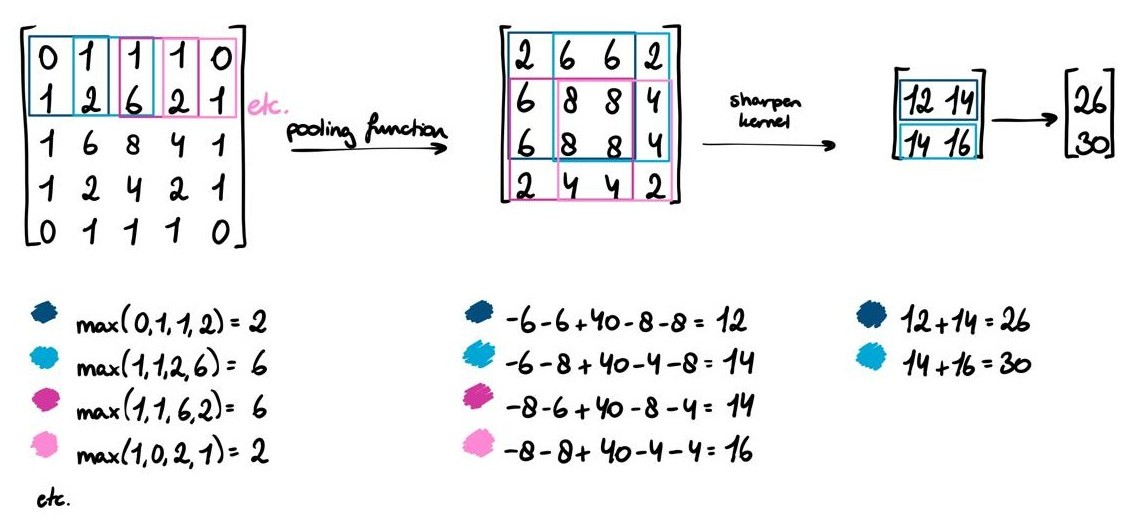

#### Question 21: Use the inputs found in Q20 and the given network architecture to find the output on neuron y.

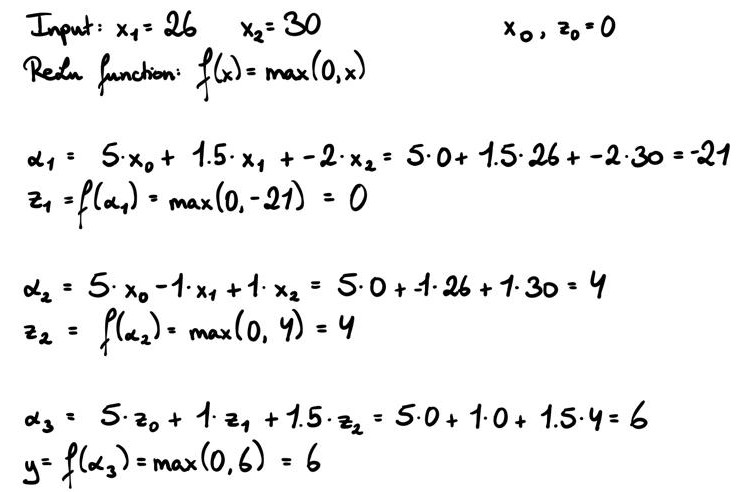

### 1.9 Division of work

#### Question 22: Indicate each group member's contribution.

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References